In [38]:

import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
import json
import pandas as pd

# 1. Daten: X (n×p), f (n,)
X = np.load("data/mds_dir_stan_data/subj_01/subj_01/mask_7_single_sample_0_both_mds.npy")  

metadata = np.load("data/rdm_dir_stan_data/subj_01/subj_01/metadata.npy")
animate_labels = pd.read_excel("data/labels/subj_01/animate_nonface/animate_non_face_final.xlsx")
face_labels = pd.read_excel("data/labels/subj_01/faces/faces_final.xlsx")

animate_labels_cocoIds = [int(x) for x in animate_labels["cocoId"].tolist()]
face_labels_cocoIds = [int(x) for x in face_labels["cocoId"].tolist()]


labels = []
for metadata_entry in metadata:
    metadata_coco = int(metadata_entry.lstrip("0"))
    if metadata_coco in animate_labels_cocoIds:
        labels.append(1)
    elif metadata_coco in face_labels_cocoIds:
        labels.append(0)
    else:
        raise Exception()

labels = np.array(labels)

face_detection_path = "data/labels/subj_01/face_detection_result.json"
with open(face_detection_path, "r") as f:
    face_detection_results = json.load(f)


filtered_face_detection_results = [x for x in face_detection_results if x["file_name"][:-4] in metadata]

In [40]:
# 2. Distanzmatrix und Ähnlichkeitsmatrix
D = squareform(pdist(X, metric='euclidean'))
# S_ij = 1 wenn gleiche Klasse, sonst 0
S = (labels[:, None] == labels[None, :]).astype(int)

# 3. Beobachtete Teststatistik
mask_within  = np.triu(S==1, k=1)
mask_between = np.triu(S==0, k=1)
mean_within  = D[mask_within].mean()
mean_between = D[mask_between].mean()
T_obs = mean_between - mean_within

# 4. Permutationstest
B = 2000
T_perm = np.empty(B)
for b in range(B):
    y_shuff = np.random.permutation(labels)
    S_b = (y_shuff[:, None] == y_shuff[None, :]).astype(int)
    mw = D[np.triu(S_b==1, k=1)].mean()
    mb = D[np.triu(S_b==0, k=1)].mean()
    T_perm[b] = mb - mw

# 5. p-Wert (einseitig: "zwischen > innerhalb")
p_value = (np.sum(T_perm >= T_obs) + 1) / (B + 1)

print(f"Mean within-class distance:  {mean_within:.4f}")
print(f"Mean between-class distance: {mean_between:.4f}")
print(f"T_obs = between − within = {T_obs:.4f}")
print(f"Permutation p-value:        {p_value:.4f}")

Mean within-class distance:  0.7845
Mean between-class distance: 0.7985
T_obs = between − within = 0.0140
Permutation p-value:        0.0010


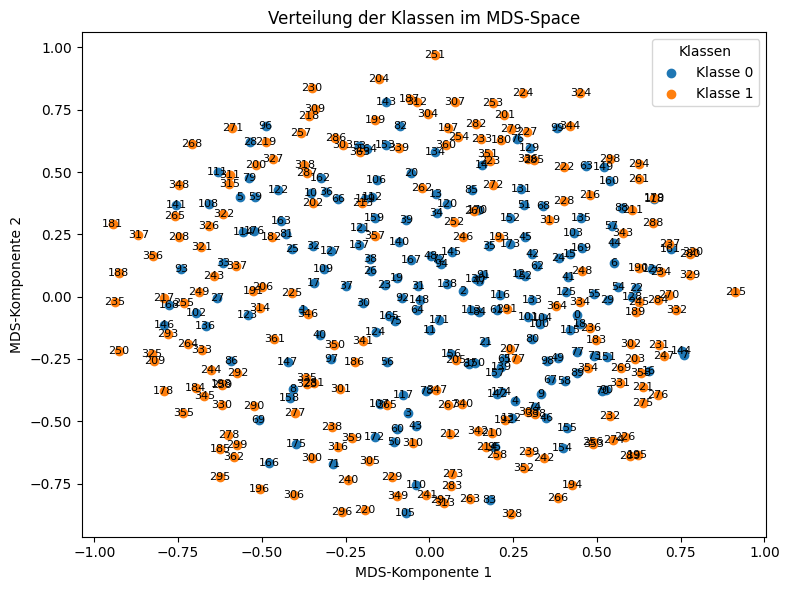

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Hier deine Daten laden/einfügen ---
# X: numpy-Array mit den MDS-Koordinaten, Form (n, 2)
# y: numpy-Array mit Binärlabels (0 oder 1), Länge n
# Beispielplatzhalter (entfernen, wenn du echte Daten hast):
# np.random.seed(0)
# X = np.random.randn(180, 2)
# y = np.random.randint(0, 2, size=180)
# ----------------------------------------

# Indizes nach Klasse aufteilen
idx0 = np.where(labels == 0)[0]
idx1 = np.where(labels == 1)[0]

fig, ax = plt.subplots(figsize=(8, 6))

# Zwei Scatter-Aufrufe, um automatisch zwei Farben aus dem Default-Zyklusschema zu nutzen
ax.scatter(X[idx0, 0], X[idx0, 1], label='Klasse_0')
ax.scatter(X[idx1, 0], X[idx1, 1], label='Klasse_1')

# Beschrifte jeden Punkt mit seiner Index-Nummer
for i in range(X.shape[0]):
    ax.text(X[i, 0], X[i, 1], str(i), fontsize=8, ha='center', va='center')

ax.set_xlabel('MDS-Komponente_1')
ax.set_ylabel('MDS-Komponente_2')
ax.set_title('Verteilung der Klassen im MDS‐Space')
ax.legend(title='Klassen')

plt.tight_layout()
plt.show()


In [13]:
print(len(face_detection_results))
print(len(filtered_face_detection_results))

print(len(metadata))
animate_labels.head()

4636
224
366


,Unnamed: 0,cocoId,cocoSplit,nsdId,file_name,amount_participants,subject,labels,label
0,0,399594,train2017,42583,train2017/000000399594.jpg,1,1,"['dog', 'dog', 'bed', 'backpack']",Accepted
1,1,280216,train2017,35190,train2017/000000280216.jpg,1,1,"['sheep', 'sheep', 'sheep', 'sheep', 'sheep', ...",Accepted
2,2,386936,train2017,39310,train2017/000000386936.jpg,1,1,"['dog', 'bed', 'book', 'book', 'book', 'book',...",Accepted
3,3,397958,train2017,42138,train2017/000000397958.jpg,1,1,"['cow', 'cow']",Accepted
4,4,31393,train2017,55562,train2017/000000031393.jpg,1,1,"['truck', 'truck', 'person', 'person']",Accepted


In [ ]:
# f = np.array(...)

# 2. Paarweise Distanzen im MDS-Space
D = squareform(pdist(X, metric='euclidean'))

# 3. Paarweise Feature-Differenzen
F = squareform(pdist(f.reshape(-1,1), metric='euclidean'))

# 4. Beobachtete Spearman-Korrelation
dists = D[np.triu_indices_from(D, k=1)]
fdiffs = F[np.triu_indices_from(F, k=1)]
T_obs, _ = spearmanr(dists, fdiffs)

# 5. Permutationstest
B = 2000
T_perm = np.zeros(B)
for b in range(B):
    f_shuff = np.random.permutation(f)
    F_b = squareform(pdist(f_shuff.reshape(-1,1), metric='euclidean'))
    fd_b = F_b[np.triu_indices_from(F_b, k=1)]
    T_perm[b], _ = spearmanr(dists, fd_b)

# 6. p-Wert
p_value = (np.sum(np.abs(T_perm) >= np.abs(T_obs)) + 1) / (B + 1)
print("Observed Spearman:", T_obs)
print("p-value:", p_value)


In [49]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

def permutation_test_knn(
    X: np.ndarray,
    y: np.ndarray,
    n_neighbors: int = 10,
    B: int = 2000,
    metric: str = 'euclidean'
) -> dict:
    """
    Führt einen Permutationstest durch, bei dem nur die n_neighbors
    nächsten Nachbarn jedes Punktes im MDS-Space betrachtet werden.

    Args:
      X            : Array der MDS-Koordinaten, Form (n, 2)
      y            : Binäres Label-Array der Länge n (0/1)
      n_neighbors  : Anzahl der nächsten Nachbarn pro Punkt
      B            : Anzahl der Permutationen
      metric       : Distanzmaß (z.B. 'euclidean')

    Returns:
      dict mit:
        - T_obs        : beobachtete Teststatistik (mean_between - mean_within)
        - p_value      : Permutations‑p‑Wert (einseitig)
        - mean_within  : mittlere Distanz innerhalb gleicher Klasse
        - mean_between : mittlere Distanz zwischen Klassen
        - T_perm       : Array aller permutierten Teststatistiken
    """
    print(X)
    n = X.shape[0]
    # 1) Distanzmatrix im MDS-Space
    D = squareform(pdist(X, metric=metric))

    # 2) Menge aller Neighbor-Paare (i<j) sammeln
    neighbor_pairs = set()
    for i in range(n):
        # argsort schließt i selbst an Position 0 aus, daher [1:...]
        nearest = np.argsort(D[i])[1 : n_neighbors + 1]
        for j in nearest:
            a, b = sorted((i, j))
            neighbor_pairs.add((a, b))
    pairs = np.array(list(neighbor_pairs))  # Form (M, 2)

    # 3) Beobachtete Abstände & Klassen‑Ähnlichkeit
    dists = D[pairs[:,0], pairs[:,1]]
    same_class = (y[pairs[:,0]] == y[pairs[:,1]])

    mean_within  = dists[same_class].mean()
    mean_between = dists[~same_class].mean()
    T_obs = mean_between - mean_within

    # 4) Permutationstest
    T_perm = np.zeros(B)
    for b in range(B):
        y_shuff = np.random.permutation(y)
        same_b = (y_shuff[pairs[:,0]] == y_shuff[pairs[:,1]])
        mw = dists[same_b].mean()
        mb = dists[~same_b].mean()
        T_perm[b] = mb - mw

    # 5) p-Wert (einseitig: "zwischen > innerhalb")
    p_value = (np.sum(T_perm >= T_obs) + 1) / (B + 1)

    return {
        'T_obs': T_obs,
        'p_value': p_value,
        'mean_within': mean_within,
        'mean_between': mean_between,
        'T_perm': T_perm
    }


# X: dein (n×2)-Array mit MDS-Koordinaten
# y: dein Binär-Label-Array (0/1)

result = permutation_test_knn(
    X,
    labels,
    n_neighbors=5,   # z.B. nur die 15 nächsten Nachbarn
    B=5000            # 5000 Permutationen für mehr Stabilität
)

print("Beobachtetes T_obs       :", result['T_obs'])
print("Mean within-class dist. :", result['mean_within'])
print("Mean between-class dist.:", result['mean_between'])
print("Permutation p-value     :", result['p_value'])


[[ 0.44044173 -0.07355472]
 [-0.37719455 -0.05375969]
 [ 0.0989932   0.02237267]
 [-0.06532804 -0.4682777 ]
 [ 0.2541857  -0.41768864]
 [-0.56530577  0.39941716]
 [ 0.5506626   0.13488707]
 [ 0.7611122  -0.2341163 ]
 [-0.4084909  -0.37130892]
 [ 0.33249605 -0.39172328]
 [-0.35320142  0.41501626]
 [ 0.0011084  -0.1324087 ]
 [ 0.2664297   0.09019364]
 [ 0.01983187  0.41196984]
 [ 0.15739115  0.52811617]
 [ 0.41928577  0.16968754]
 [ 0.6554237  -0.29783845]
 [-0.34546608  0.05652365]
 [ 0.4480501  -0.11020956]
 [-0.0967316   0.07406216]
 [-0.05375522  0.49528328]
 [ 0.16583067 -0.18195118]
 [ 0.61703855  0.03374015]
 [-0.13363026  0.04651325]
 [ 0.38537824  0.15498768]
 [-0.40871534  0.1926474 ]
 [-0.17537451  0.10301086]
 [-0.63416576 -0.00390089]
 [-0.535022    0.6199296 ]
 [ 0.53178036 -0.01199837]
 [-0.19889612 -0.02459903]
 [-0.03402954  0.04157391]
 [-0.34737852  0.20493454]
 [-0.616722    0.13572702]
 [ 0.02121605  0.33705708]
 [ 0.17793426  0.2041479 ]
 [-0.3088586   0.4189172 ]
 

In [52]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

def permutation_test_knn_ratio(
    X: np.ndarray,
    y: np.ndarray,
    n_neighbors: int = 10,
    B: int = 2000,
    metric: str = 'euclidean'
) -> dict:
    """
    Permutationstest basierend auf Count-Statistik der N nächsten Nachbarn.

    Für jedes Sample i:
      - Finde die n_neighbors nächsten Nachbarn im MDS-Space.
      - Zähle, wie viele davon die gleiche Klasse haben (same_count).
      - Zähle, wie viele anders sind (diff_count).

    Aggregiere über alle i:
      same_total = Summe aller same_count
      diff_total = Summe aller diff_count
      ratio_obs = same_total / diff_total

    Führe B Permutationen der Labels durch, berechne ratio_perm[b] analog.
    Liefert p-Wert für Einseitigen Test (ratio_perm >= ratio_obs).

    Args:
      X            : MDS-Koordinaten, Array der Form (n, 2)
      y            : Binär-Labels (0/1), Länge n
      n_neighbors  : Anzahl der Nachbarn je Punkt
      B            : Anzahl der Permutationen
      metric       : Distanz-Metrik für pdist (z.B. 'euclidean')

    Returns:
      dict mit folgenden Einträgen:
        - ratio_obs   : beobachtetes Verhältnis same/diff
        - p_value     : Permutations-p-Wert (einseitig)
        - same_total  : absolute Anzahl gleichklassiger Nachbarn
        - diff_total  : absolute Anzahl ungleichklassiger Nachbarn
        - ratio_perm  : Array der permutierten Verhältnisse der Länge B
    """
    n = X.shape[0]
    # 1) Paarweise Distanzen
    D = squareform(pdist(X, metric=metric))

    # 2) Für jedes i seine N nächsten Nachbarn bestimmen
    neighbors = [np.argsort(D[i])[1 : n_neighbors + 1] for i in range(n)]

    # 3) Beobachtete Counts
    same_total = 0
    diff_total = 0
    for i, neigh in enumerate(neighbors):
        same = np.sum(y[neigh] == y[i])
        diff = n_neighbors - same
        # print(f"{i}: {same}\t{diff}")

        same_total += same
        diff_total += diff
    ratio_obs = same_total / diff_total

    # 4) Permutationstest
    ratio_perm = np.empty(B)
    for b in range(B):
        y_shuff = np.random.permutation(y)
        st = 0
        dt = 0
        for i, neigh in enumerate(neighbors):
            st += np.sum(y_shuff[neigh] == y_shuff[i])
            dt += n_neighbors - np.sum(y_shuff[neigh] == y_shuff[i])
        ratio_perm[b] = st / dt

    # 5) p-Wert (einseitig: ratio_perm >= ratio_obs)
    p_value = (np.sum(ratio_perm >= ratio_obs) + 1) / (B + 1)

    return {
        'ratio_obs': ratio_obs,
        'p_value': p_value,
        'same_total': same_total,
        'diff_total': diff_total,
        'ratio_perm': ratio_perm
    }


# X = dein (n×2)-Array mit MDS-Koordinaten
# y = dein Binär-Label-Array (0/1)

res = permutation_test_knn_ratio(X, labels, n_neighbors=3, B=10000)
print(f"Beobachtetes Ratio (same/diff): {res['ratio_obs']:.3f}")
print(f"Permutation p-value            : {res['p_value']:.4f}")



Beobachtetes Ratio (same/diff): 1.608
Permutation p-value            : 0.0001


In [53]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

def morans_I_permutation(
    X: np.ndarray,
    y: np.ndarray,
    k: int = 10,
    B: int = 2000,
    metric: str = 'euclidean'
) -> dict:
    """
    Berechnet Global Moran’s I für binäre Labels y mit k‑NN-Gewichten
    und ermittelt seine Signifikanz per Permutationstest.

    Args:
      X      : Array der MDS‑Koordinaten, Form (n, 2) (oder beliebig p‑dimensional)
      y      : Binär‑Labels (0/1), Länge n
      k      : Anzahl der nächsten Nachbarn für die Gewichts‑Matrix W
      B      : Anzahl der Permutationen
      metric : Distanzmaß für pdist (z.B. 'euclidean')

    Returns:
      dict mit:
        - I_obs   : beobachtetes Moran’s I
        - p_value : Permutations‑p‑Wert (einseitig: I_perm ≥ I_obs)
        - I_perm  : Array der permutierten Moran’s I (Länge B)
    """
    n = len(y)
    # 1) Paarweise Distanzen und kNN‑Graph
    D = squareform(pdist(X, metric=metric))
    W = np.zeros((n, n), dtype=int)
    for i in range(n):
        # nächstgelegene k Nachbarn (ohne i selbst)
        nbrs = np.argsort(D[i])[1:k+1]
        W[i, nbrs] = 1
    # symmetrisch machen (ungerichteter Graph)
    W = ((W + W.T) > 0).astype(int)
    S0 = W.sum()

    # 2) Beobachtetes Moran’s I
    y_bar = y.mean()
    num = np.sum(W * (y[:, None] - y_bar) * (y[None, :] - y_bar))
    den = np.sum((y - y_bar) ** 2)
    I_obs = (n / S0) * (num / den)

    # 3) Permutationstest
    I_perm = np.zeros(B)
    for b in range(B):
        y_p = np.random.permutation(y)
        num_p = np.sum(W * (y_p[:, None] - y_bar) * (y_p[None, :] - y_bar))
        I_perm[b] = (n / S0) * (num_p / den)

    # 4) p‑Wert (einseitig)
    p_value = (np.sum(I_perm >= I_obs) + 1) / (B + 1)

    return {
        'I_obs': I_obs,
        'p_value': p_value,
        'I_perm': I_perm
    }

res = morans_I_permutation(X, labels, k=5, B=1000)
print(f"Beobachtetes Ratio (same/diff): {res['I_obs']:.3f}")
print(f"Permutation p-value            : {res['p_value']:.4f}")

Beobachtetes Ratio (same/diff): 0.201
Permutation p-value            : 0.0010


Kurze Übersicht weiterer Verfahren

    Join‑Count‑Statistik

        Graph: k‑NN oder Delaunay‑Triangulation

        Zähle Kanten BB (0–0), WW (1–1) und BW (0–1)

        Permutation der Labels → Nullverteilung für z. B. BB+WW

    Cuzick‑Edwards k‑NN‑Test

        Für jede „Fall“-Probe (Label 1) zähle, wie viele ihrer k NN ebenfalls Fälle sind

        Summe über alle Fälle → Teststatistik

        Permutation der Labels liefert Signifikanz

    Ripley’s K/L‑Funktion (cross‑K)

        Untersuche für verschiedene Radien r, ob Fälle und Kontrollen sich mischen oder clustern

        Vergleich der empirischen K₁₂(r) mit Simulationen randomisierter Labels

    Local Moran’s I / LISA

        Lokale Autokorrelationsstatistik pro Punkt

        Identifikation von „Hot Spots“ und „Cold Spots“

        Ergänzt Global‑Moran um lokale Detailinformation

    Getis‑Ord G*‑Statistik

        Misst Lokalisierte Cluster hoher bzw. niedriger Werte

        Ebenfalls permutativ testbar auf binäre oder kontinuierliche Attribute

In [ ]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
import json
import pandas as pd

# 1. Daten: X (n×p), f (n,)
X = np.load("data/mds_stan_data_face_only/subj_01/subj_01/mask_7_averaged_both_mds.npy")  

metadata = np.load("data/rdm_stan_data_face_only/subj_01/subj_01/metadata.npy")
animate_labels = pd.read_excel("data/labels/subj_01/animate_nonface/animate_non_face_final.xlsx")
face_labels = pd.read_excel("data/labels/subj_01/faces/faces_final.xlsx")

animate_labels_cocoIds = [int(x) for x in animate_labels["cocoId"].tolist()]
face_labels_cocoIds = [int(x) for x in face_labels["cocoId"].tolist()]


labels = []
for metadata_entry in metadata:
    metadata_coco = int(metadata_entry.lstrip("0"))
    if metadata_coco in animate_labels_cocoIds:
        labels.append(1)
    elif metadata_coco in face_labels_cocoIds:
        labels.append(0)
    else:
        raise Exception()

labels = np.array(labels)

face_detection_path = "data/labels/subj_01/face_detection_result.json"
with open(face_detection_path, "r") as f:
    face_detection_results = json.load(f)


filtered_face_detection_results = [x for x in face_detection_results if x["file_name"][:-4] in metadata]